In [1]:
import os
import random
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import splitfolders

from IPython.display import display
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.densenet import (DenseNet121,
                                                    preprocess_input)
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.layers import (BatchNormalization, Dense,
                                     Dropout, Flatten, Input)
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
SEED = 123

### Explore the COVID-19 radiography dataset

In [3]:

DATASET_PATH = '../data_sources/covid-19_radiography_dataset'
dir_list = os.listdir(DATASET_PATH)
print(dir_list)

['COVID', 'Lung Opacity', 'Normal', 'Viral Pneumonia']


In [4]:
num_of_images = []
for root, dirs, files in os.walk(DATASET_PATH):
    if root == DATASET_PATH: continue
    print('{}: {}'.format(os.path.basename(root), len(files)))
    num_of_images.append(len(files))

COVID: 3616
Lung Opacity: 6012
Normal: 10192
Viral Pneumonia: 1345


path: ../data_sources/covid-19_radiography_dataset\COVID\COVID-2542.png
size: (299, 299)
mode: L
format: PNG


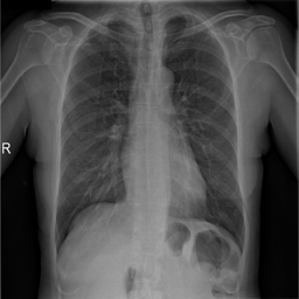

In [5]:
SEED = 123
random.seed(SEED)
rand_img = Image.open(random.choice(glob(DATASET_PATH + '/**/*')))

print('path:', rand_img.filename)
print('size:', rand_img.size)
print('mode:', rand_img.mode)
print('format:', rand_img.format)
display(rand_img)

### Visualize the COVID-19 radiography dataset

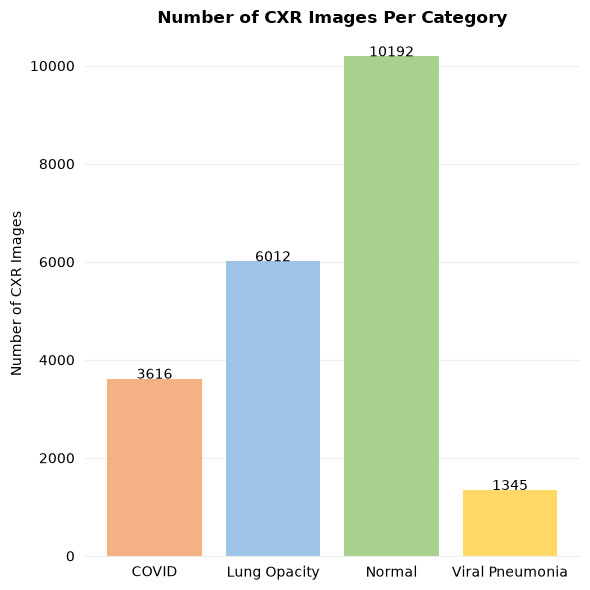

In [6]:
x_coord = np.arange(len(dir_list))
colors = ['#f4b183', '#9dc3e6', '#a9d18e', '#ffd966']

fig, ax = plt.subplots(facecolor='white', figsize=(6,6))
ax.bar(x_coord, num_of_images, color=colors)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#EEEEEE')

ax.yaxis.grid(True, color='#EEEEEE')
ax.set_axisbelow(True)

plt.xticks(x_coord, dir_list)
ax.tick_params(bottom=False, left=False)

plt.title('Number of CXR Images Per Category', fontweight='bold')
plt.ylabel('Number of CXR Images')

for i in range(len(x_coord)):
    plt.text(i, num_of_images[i], num_of_images[i], ha='center')

plt.tight_layout()
plt.savefig('figures/bar_chart.png', dpi=200)
plt.show()

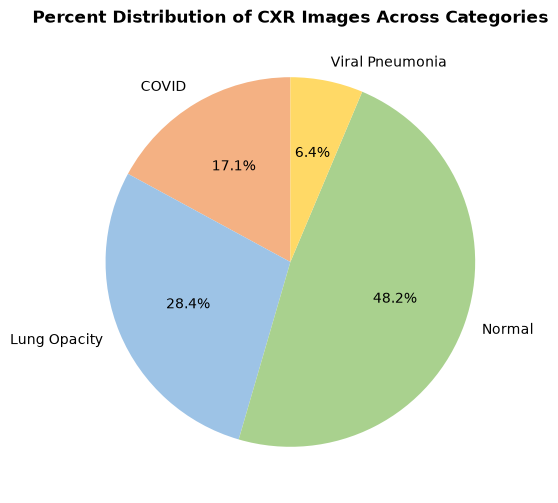

In [ ]:
plt.figure(facecolor='white', figsize=(6,6))
plt.pie(num_of_images,
        labels=dir_list,
        colors=colors,
        autopct='%.1f%%',
        startangle=90)
plt.title('Percent Distribution of CXR Images Across Categories', fontweight='bold')
plt.savefig('figures/pie_chart.png', dpi=200)
plt.show()

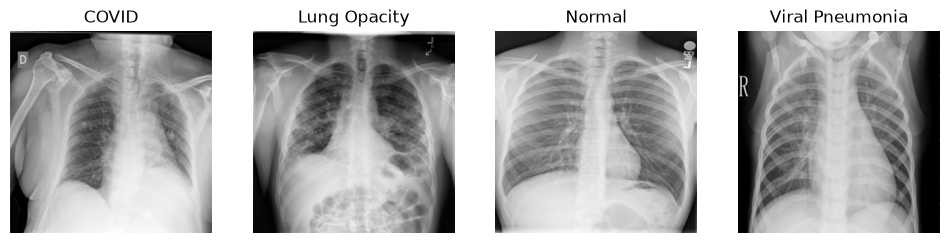

In [8]:
plt.figure(facecolor='white', figsize=(12,3))
for i in range(4):
    ax = plt.subplot(1, 4, i + 1)
    path = random.choice(glob(DATASET_PATH + '/' + dir_list[i] + '/*'))
    plt.imshow(Image.open(path), cmap='gray')
    plt.title(dir_list[i])
    plt.axis('off')
plt.savefig('figures/random_images.png', dpi=200)
plt.show()

### Preprocess the COVID-19 radiography dataset

In [11]:
OUTPUT_PATH = '../data/dataset_subsets'
if not os.path.exists(OUTPUT_PATH):
    splitfolders.ratio(DATASET_PATH, OUTPUT_PATH, SEED, (.7, .1, .2))

In [12]:
IMG_DIMS = 224
TARGET_SIZE = (IMG_DIMS, IMG_DIMS)
COLOR_MODE = 'rgb'
CLASS_MODE = 'categorical'
BATCH_SIZE = 32

In [13]:
TRAIN_PATH = os.path.join(OUTPUT_PATH, 'train')
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.9, 1.1],
    zoom_range=[0.9, 1.1],
    horizontal_flip=True)
train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=TARGET_SIZE,
    color_mode=COLOR_MODE,
    class_mode=CLASS_MODE,
    batch_size=BATCH_SIZE,
    seed=SEED)

Found 14814 images belonging to 4 classes.


In [14]:
VAL_PATH = os.path.join(OUTPUT_PATH, 'val')
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input)
val_gen = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=TARGET_SIZE,
    color_mode=COLOR_MODE,
    class_mode=CLASS_MODE,
    batch_size=BATCH_SIZE,
    seed=SEED)

Found 2115 images belonging to 4 classes.


In [15]:
TEST_PATH = os.path.join(OUTPUT_PATH, 'test')
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=TARGET_SIZE,
    color_mode=COLOR_MODE,
    class_mode=CLASS_MODE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED)

Found 4236 images belonging to 4 classes.


### Analyze the COVID-19 radiography dataset

In [ ]:
print(train_gen.directory)
print(val_gen.directory)
print(test_gen.directory)

../data/dataset_subsets\train
../data/dataset_subsets\val
../data/dataset_subsets\test


In [17]:
print(train_gen.class_indices)

{'COVID': 0, 'Lung Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


In [ ]:
images, labels = next(iter(train_gen))
print('images shape:', images.shape)  
print('labels shape:', labels.shape)

images shape: (32, 224, 224, 3)
labels shape: (32, 4)


### Build a customized DenseNet121 model

In [ ]:
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_tensor=Input(shape=(IMG_DIMS, IMG_DIMS, 3)),
    input_shape=(IMG_DIMS, IMG_DIMS, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.4))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [ ]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50176)          │       200,704 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    51,381,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,282,756 (226.15 MB)

 Trainable params: 52,141,828 (198.91 MB)

 Non-trainable params: 7,140,928 (27.24 MB)

### Train the customized DenseNet121 model

In [ ]:

EPOCHS = 25
ETA = 0.0001

In [ ]:

METRICS = ['categorical_accuracy', Precision(), Recall()]

In [ ]:

model.compile(optimizer=Adam(ETA),
              loss='categorical_crossentropy',
              metrics=METRICS)

In [ ]:

def scheduler(epoch):
    if epoch > 19:
        return ETA * 0.1
    else:
        return ETA
callback = LearningRateScheduler(scheduler)

In [ ]:

cls_wt = compute_class_weight(class_weight='balanced',
                              classes=np.unique(train_gen.labels),
                              y=train_gen.labels)
class_weight = {0: cls_wt[0], 1: cls_wt[1], 2: cls_wt[2], 3: cls_wt[3]}
print(class_weight)

{0: np.float64(1.4632556301856974), 1: np.float64(0.8801093155893536), 2: np.float64(0.5191337258200168), 3: np.float64(3.9357066950053134)}


In [ ]:

history = model.fit(train_gen,
                    epochs=EPOCHS,
                    callbacks=callback,
                    validation_data=val_gen,
                    class_weight=class_weight)

Epoch 1/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 318s 613ms/step - categorical_accuracy: 0.7830 - loss: 0.4765 - precision: 0.8160 - recall: 0.7459 - val_categorical_accuracy: 0.8931 - val_loss: 0.3176 - val_precision: 0.9075 - val_recall: 0.8771 - learning_rate: 1.0000e-04
Epoch 2/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 246s 530ms/step - categorical_accuracy: 0.8525 - loss: 0.3176 - precision: 0.8651 - recall: 0.8348 - val_categorical_accuracy: 0.9045 - val_loss: 0.2845 - val_precision: 0.9089 - val_recall: 0.8960 - learning_rate: 1.0000e-04
Epoch 3/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 251s 542ms/step - categorical_accuracy: 0.8659 - loss: 0.2896 - precision: 0.8770 - recall: 0.8518 - val_categorical_accuracy: 0.9069 - val_loss: 0.2662 - val_precision: 0.9107 - val_recall: 0.9017 - learning_rate: 1.0000e-04
Epoch 4/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 252s 544ms/step - categorical_accuracy: 0.8775 - loss: 0.2576 - precision: 0.8868 - recall: 0.8668 - val_categorical_accuracy: 0.9050 - val_loss: 0.2566 - val_pre

### Visualize the training results

In [ ]:
import os

def plot_metric_history(metric, val_metric, y_label, title):
    plt.figure(facecolor='white', figsize=(8, 6))
    plt.plot(history.history[metric])
    plt.plot(history.history[val_metric])
    plt.ylabel(y_label)
    plt.xlabel('epoch')
    plt.title(title)
    plt.legend(['training', 'validation'])
    if not os.path.exists('figures'):
        os.makedirs('figures')

    plt.savefig('figures/' + y_label + '.png', dpi=200)
    plt.show()

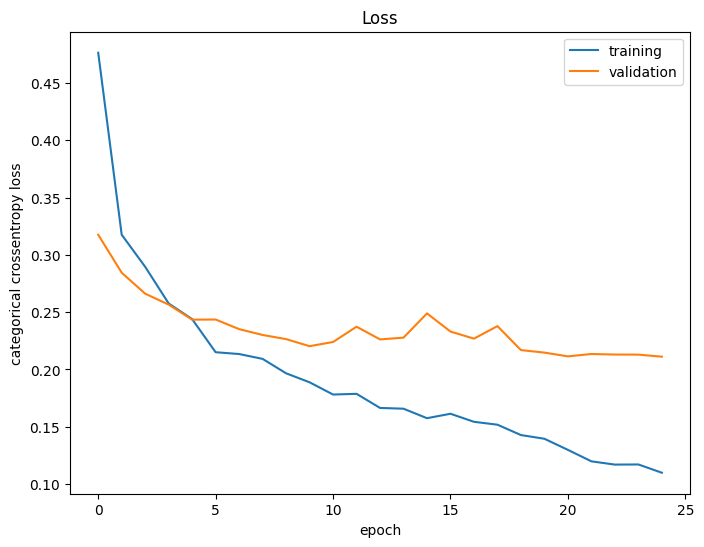

In [ ]:

plot_metric_history(metric='loss',
                    val_metric='val_loss',
                    y_label='categorical crossentropy loss',
                    title='Loss')

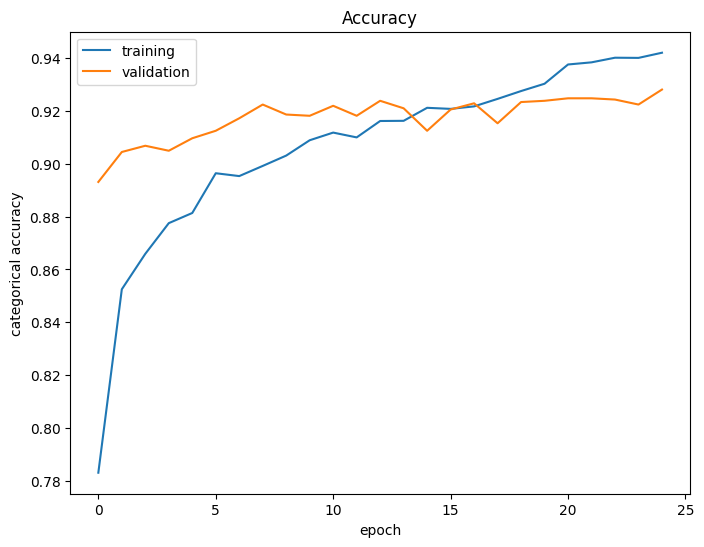

In [ ]:

plot_metric_history(metric='categorical_accuracy',
                    val_metric='val_categorical_accuracy',
                    y_label='categorical accuracy',
                    title='Accuracy')

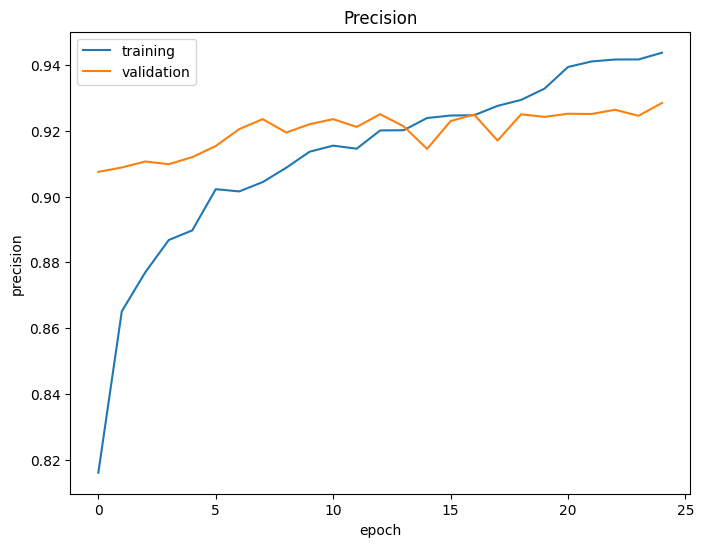

In [ ]:

plot_metric_history(metric='precision',
                    val_metric='val_precision',
                    y_label='precision',
                    title='Precision')

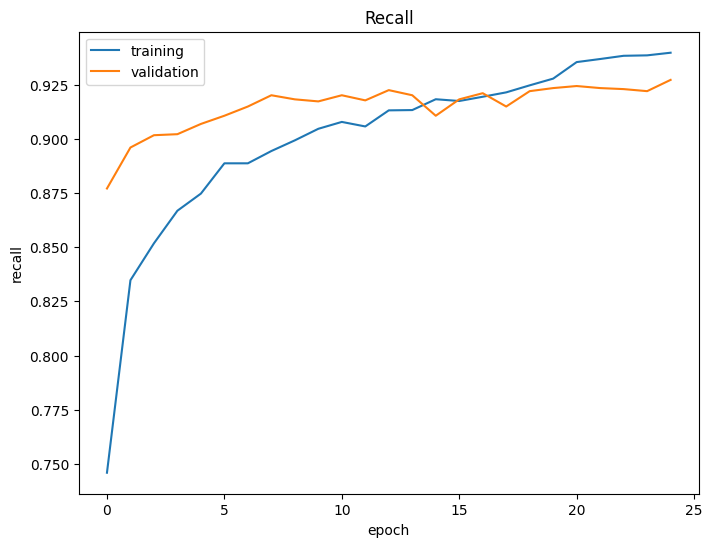

In [ ]:

plot_metric_history(metric='recall',
                    val_metric='val_recall',
                    y_label='recall',
                    title='Recall')

### Evaluate the customized DenseNet121 model

In [ ]:

result = model.evaluate(test_gen)
dict(zip(model.metrics_names, result))

133/133 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - categorical_accuracy: 0.9313 - loss: 0.2030 - precision: 0.9323 - recall: 0.9301


{'loss': 0.2029954046010971, 'compile_metrics': 0.9313031435012817}

In [ ]:

predictions = model.predict(test_gen)

133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step


In [ ]:

y_true = test_gen.labels
y_pred = np.argmax(predictions, axis=1)

In [ ]:

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       724
           1       0.91      0.89      0.90      1203
           2       0.93      0.94      0.94      2039
           3       0.97      0.98      0.98       270

    accuracy                           0.93      4236
   macro avg       0.94      0.94      0.94      4236
weighted avg       0.93      0.93      0.93      4236



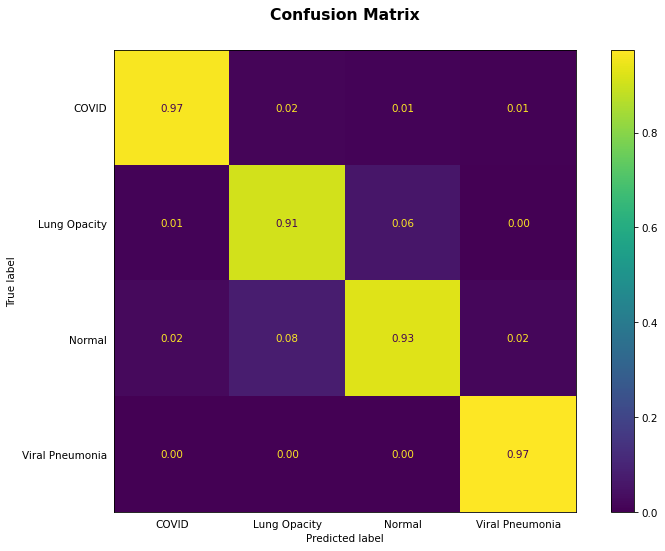

In [ ]:

fig, ax = plt.subplots(facecolor='white', figsize=(12, 8), dpi=75)
fig = ConfusionMatrixDisplay.from_predictions(y_true,
                                              y_pred,
                                              display_labels=test_gen.class_indices,
                                              include_values=True,
                                              normalize='pred',
                                              values_format='.2f',
                                              cmap='viridis',
                                              ax=ax)
plt.tick_params(left=False, bottom=False)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold', pad=30)
plt.savefig('figures/confusion_matrix.png', dpi=200)
plt.show()